```markdown
# Semana 1 - Día 3 (Extra): Hiperparámetros, Activaciones y Regresión
**Especialización en Ciencia de Datos e Inteligencia Artificial**

En los notebooks anteriores aprendimos a construir y evaluar Redes Neuronales Multicapa (MLP) para clasificación. Sin embargo, en el mundo real, el primer modelo que construimos casi nunca es el mejor.

Hoy nos pondremos la bata de "Científicos" para experimentar con las "perillas" de nuestra red (Hiperparámetros):
1. **La Función de Activación:** ¿Qué pasa si cambiamos la forma en que "piensan" las neuronas ocultas?
2. **La Tasa de Aprendizaje (Learning Rate):** ¿Qué pasa si le pedimos al gradiente descendente que dé pasos gigantes o pasos de hormiga?
3. **Dropout:** Una técnica maestra para evitar que la red memorice (Sobreajuste).
4. **Regresión:** ¿Y si no queremos predecir una categoría, sino un número continuo (ej. el precio de una casa)?

---

## PARTE 1: Clasificación y la Tasa de Aprendizaje (Dataset Iris)
Vamos a usar uno de los datasets más famosos del mundo: **Iris**. El objetivo es clasificar 3 especies de flores (Setosa, Versicolor, Virginica) basándonos en el largo y ancho de sus pétalos y sépalos.

```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD

# 1. CARGAMOS Y PREPARAMOS LOS DATOS DE LAS FLORES
iris = load_iris()
X_flores = iris.data
y_flores = iris.target # Clases: 0, 1, 2


In [ ]:
print(X_flores)
print/(Y_flores)

In [ ]:

# Escalamos los datos (vital para que el gradiente funcione bien)
escalador = StandardScaler()
X_flores_escalado = escalador.fit_transform(X_flores)

# Dividimos en Train y Test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_flores_escalado, y_flores, test_size=0.2, random_state=42)

print(f"Tenemos {len(X_train_f)} flores para entrenar y {len(X_test_f)} para probar.")

Tenemos 120 flores para entrenar y 30 para probar.


```markdown
### Experimento A: El impacto de la Función de Activación
Hasta ahora hemos mencionado `sigmoid` y `relu`. Vamos a entrenar dos modelos idénticos, pero uno usará neuronas `sigmoid` en sus capas ocultas y el otro `relu`. Veremos cuál aprende más rápido.

```

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo con Sigmoide...
Entrenando modelo con ReLU...


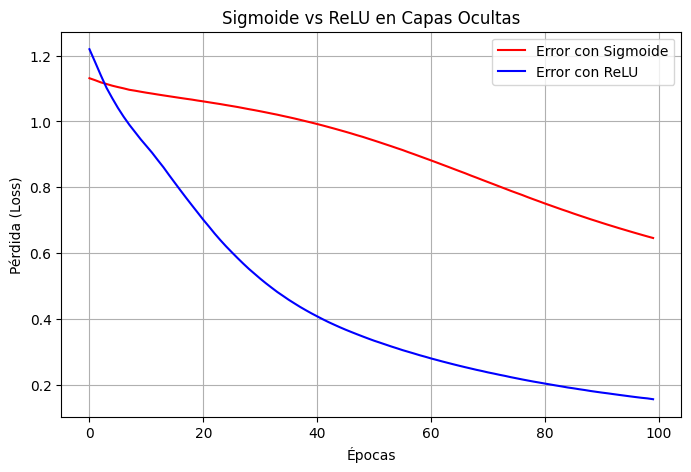

In [ ]:
# Función auxiliar para crear modelos rápidamente
def crear_modelo_flores(activacion_oculta):
    modelo = Sequential()
    modelo.add(Dense(16, input_dim=4, activation=activacion_oculta))
    modelo.add(Dense(8, activation=activacion_oculta))
    # Capa de salida: 3 neuronas (por las 3 especies) y 'softmax' para probabilidades
    modelo.add(Dense(3, activation='softmax'))

    # Usamos sparse_categorical_crossentropy porque nuestras etiquetas son 0, 1, 2
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return modelo

# Creamos y entrenamos ambos modelos
modelo_sigmoide = crear_modelo_flores(activacion_oculta='sigmoid')
modelo_relu = crear_modelo_flores(activacion_oculta='relu')

print("Entrenando modelo con Sigmoide...")
historial_sigmoide = modelo_sigmoide.fit(X_train_f, y_train_f, epochs=100, verbose=0)

print("Entrenando modelo con ReLU...")
historial_relu = modelo_relu.fit(X_train_f, y_train_f, epochs=100, verbose=0)

# Comparamos visualmente
plt.figure(figsize=(8,5))
plt.plot(historial_sigmoide.history['loss'], label='Error con Sigmoide', color='red')
plt.plot(historial_relu.history['loss'], label='Error con ReLU', color='blue')
plt.title("Sigmoide vs ReLU en Capas Ocultas")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.legend()
plt.grid(True)
plt.show()

# Análisis para la clase:
# ReLU (Rectified Linear Unit) suele aprender mucho más rápido porque no sufre
# del "desvanecimiento del gradiente" (cuando la derivada se vuelve casi cero en los extremos de la curva sigmoide).

```markdown
### Experimento B: La Tasa de Aprendizaje (Learning Rate - $\alpha$)
El optimizador `Adam` por defecto tiene una tasa de aprendizaje de `0.001`. ¿Qué pasa si "alteramos" la brújula matemática?
* **Tasa muy alta (0.1):** Pasos gigantes. Puede saltarse el valle del error y rebotar.
* **Tasa muy baja (0.0001):** Pasos microscópicos. Tardará una eternidad en aprender.

```

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


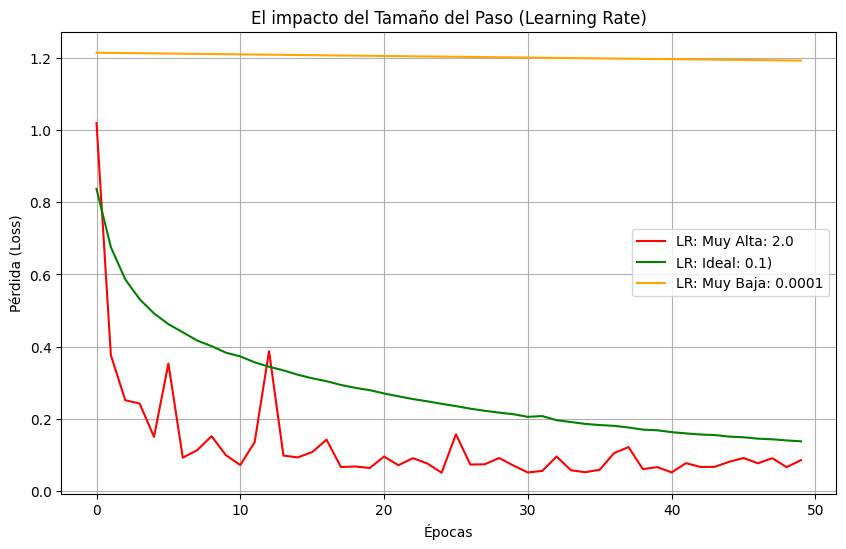

In [ ]:
# Entrenaremos 3 modelos variando solo la tasa de aprendizaje del optimizador Adam

tasas = [2.0, 0.1, 0.0001]
colores = ['red', 'green', 'orange']
nombres = [f'Muy Alta: {tasas[0]}',
           f'Ideal: {tasas[1]}',
           f'Muy Baja: {tasas[2]}']

plt.figure(figsize=(10,6))

for tasa, color, nombre in zip(tasas, colores, nombres):
    modelo_lr = Sequential()
    modelo_lr.add(Dense(16, input_dim=4, activation='relu'))
    modelo_lr.add(Dense(3, activation='softmax'))

    # Aquí es donde modificamos el Learning Rate (lr)
    optimizador_modificado = SGD(learning_rate=tasa)

    modelo_lr.compile(optimizer=optimizador_modificado, loss='sparse_categorical_crossentropy')
    hist_lr = modelo_lr.fit(X_train_f, y_train_f, epochs=50, verbose=0)

    plt.plot(hist_lr.history['loss'], label=f'LR: {nombre}', color=color)

plt.title("El impacto del Tamaño del Paso (Learning Rate)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (Loss)")
plt.legend()
plt.grid(True)
plt.show()

---

```markdown
## PARTE 2: Regresión y la magia del Dropout (Dataset Inmobiliario)
Cambiemos de problema. Ya no queremos clasificar (0 o 1). Queremos que la red escupa un número continuo.
Imagina que trabajamos en una inmobiliaria y queremos **predecir el precio medio de una casa en California** basándonos en variables como el número de habitaciones, el ingreso del vecindario, la edad de la casa, etc.

**Reglas de Keras para Regresión:**
1. La capa de salida debe tener **1 sola neurona**.
2. La capa de salida **NO tiene función de activación** (o se usa `activation='linear'`), porque queremos que el número pueda ser cualquier valor (ej. $250,000), no una probabilidad entre 0 y 1.
3. La función de pérdida (Loss) cambia a **`mse`** (Error Cuadrático Medio - Mean Squared Error) o **`mae`** (Error Absoluto Medio).

```

In [ ]:
from sklearn.datasets import fetch_california_housing

# 1. CARGAMOS DATOS INMOBILIARIOS
casas = fetch_california_housing()
X_casas = casas.data
y_precios = casas.target # El precio continuo en cientos de miles de dólares

# Dividimos y Escalamos (En regresión, si no escalas las entradas, la red colapsa)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_casas, y_precios, test_size=0.2, random_state=42)

escalador_casas = StandardScaler()
X_train_c_esc = escalador_casas.fit_transform(X_train_c)
X_test_c_esc = escalador_casas.transform(X_test_c) # Usamos transform, no fit_transform en test

```markdown
### Introduciendo el "Dropout" (Deserción)
Cuando una red neuronal es muy grande, algunas neuronas se vuelven "perezosas" y dejan que otras hagan el trabajo, o memorizan datos específicos de entrenamiento (Sobreajuste).

**Dropout** es una técnica brutal pero efectiva: En cada paso de entrenamiento, **"apaga" aleatoriamente un porcentaje de las neuronas**. Esto obliga a todas las neuronas a trabajar y a no depender excesivamente de una sola característica, haciendo al modelo mucho más robusto.

```

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenando modelo de precios con Dropout...
¡Entrenamiento finalizado!


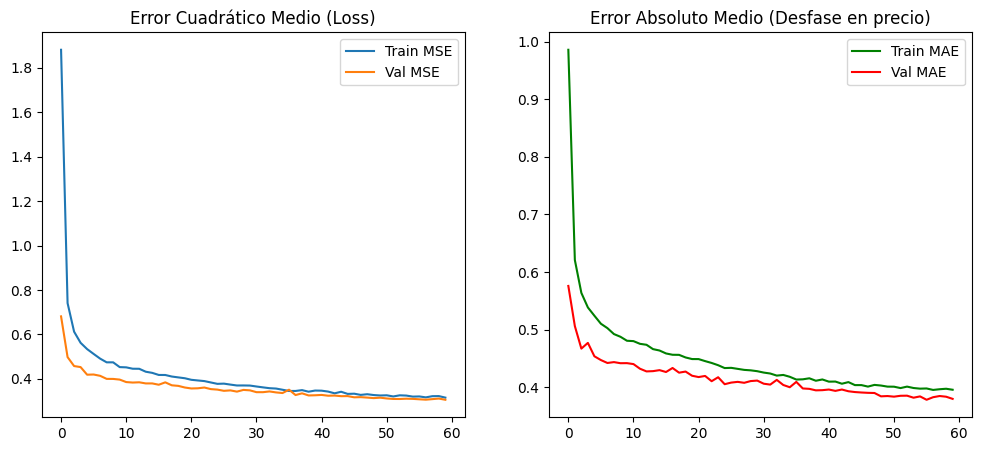


--- TASACIÓN AUTOMÁTICA ---
Precio Real de la casa: $47,700.00
Predicción del Modelo: $59,846.15
Margen de error en esta predicción: $12,146.15


In [ ]:
# Vamos a crear una red robusta para predecir precios, usando Dropout
modelo_casas = Sequential()

# Capa oculta 1 (con 64 neuronas para 8 variables de entrada)
modelo_casas.add(Dense(64, input_dim=8, activation='relu'))

# ¡AÑADIMOS DROPOUT! El 20% (0.2) de las neuronas de la capa anterior se apagarán al azar en cada paso
modelo_casas.add(Dropout(0.2))

# Capa oculta 2
modelo_casas.add(Dense(32, activation='relu'))
modelo_casas.add(Dropout(0.2)) # Otro Dropout para proteger esta capa

# Capa de salida (1 neurona, sin activación para predecir el precio real)
modelo_casas.add(Dense(1))

# Compilamos usando el Error Cuadrático Medio (mse)
modelo_casas.compile(optimizer='adam', loss='mse', metrics=['mae']) # mae = Mean Absolute Error (dólares de desfase)

print("Entrenando modelo de precios con Dropout...")
# Usamos un validation_split rápido del 20%
historial_casas = modelo_casas.fit(X_train_c_esc, y_train_c, epochs=60, validation_split=0.2, batch_size=64, verbose=0)
print("¡Entrenamiento finalizado!")

# Evaluamos cómo caen los errores
plt.figure(figsize=(12, 5))

# Gráfica del MSE (La función que el modelo optimiza)
plt.subplot(1, 2, 1)
plt.plot(historial_casas.history['loss'], label='Train MSE')
plt.plot(historial_casas.history['val_loss'], label='Val MSE')
plt.title('Error Cuadrático Medio (Loss)')
plt.legend()

# Gráfica del MAE (Más fácil de interpretar para humanos)
plt.subplot(1, 2, 2)
plt.plot(historial_casas.history['mae'], label='Train MAE', color='green')
plt.plot(historial_casas.history['val_mae'], label='Val MAE', color='red')
plt.title('Error Absoluto Medio (Desfase en precio)')
plt.legend()

plt.show()

# ---------------------------------------------------------
# PRUEBA EN LA VIDA REAL
# Vamos a pedirle a la red que tase la primera casa del set de pruebas
# ---------------------------------------------------------
casa_ejemplo = X_test_c_esc[0].reshape(1, -1)
precio_real = y_test_c[0]
precio_predicho = modelo_casas.predict(casa_ejemplo, verbose=0)[0][0]

print("\n--- TASACIÓN AUTOMÁTICA ---")
# Multiplicamos por 100,000 porque el dataset original está en esa escala
print(f"Precio Real de la casa: ${precio_real * 100000:,.2f}")
print(f"Predicción del Modelo: ${precio_predicho * 100000:,.2f}")
print(f"Margen de error en esta predicción: ${abs(precio_real - precio_predicho) * 100000:,.2f}")